# 5240 and 5340 Model Validation

## Setup

In [1]:
import importlib
import logging
import pathlib
import re
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from use_core import constants, run_info, task

sys.path.insert(0, "..")
build_models = importlib.import_module("build-models")

sns.set()

run_info.logger.setLevel(logging.CRITICAL)

In [2]:
class MockRunConfig:
    def __init__(
        self,
        dedup_ratio: float,
        kb_transferred: int,
        num_streams: int,
        task: str,
        workload_type: str,
        io_duplex: task.TaskDuplexType,
    ) -> None:
        self.dedup_ratio = dedup_ratio
        self.kb_transferred = kb_transferred
        self.num_streams = num_streams
        self.task = task
        self.workload_type = workload_type
        self.io_duplex = io_duplex

class MockApplianceConfig:
    def __init__(
        self,
        appliance: str,
        site_version: str,
        memory: int,
        number_of_total_drives: int,
    ) -> None:
        self.appliance = appliance
        self.site_version = site_version
        self.memory = memory
        self.number_of_total_drives = number_of_total_drives

In [3]:
## 5240

In [4]:
mock_run_config = MockRunConfig(0.47, 1000000, 10, "backup", "default", task.TaskDuplexType.half)
mock_appliance_config = MockApplianceConfig("5240", constants.SoftwareVersion.VER8_2, 256 * 1024 * 1024, 4)
ri = run_info.RunInfo(mock_run_config,
                      mock_appliance_config,
                      retrain=True,
                      root_data_dir="../data",
                      model_dir="../src/core/use_core/conf/models")

In [5]:
fitted_model = ri.cpu_model
# ignore the RuntimeWarning
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    summary = fitted_model.summary()
summary

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:         cpu_usage_secs   R-squared (uncentered):                   0.984
Model:                            OLS   Adj. R-squared (uncentered):              0.983
Method:                 Least Squares   F-statistic:                              911.9
Date:                Mon, 05 Oct 2020   Prob (F-statistic):                    1.37e-27
Time:                        15:33:55   Log-Likelihood:                         -160.08
No. Observations:                  32   AIC:                                      324.2
Df Residuals:                      30   BIC:                                      327.1
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================================
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
kb_transferred                 0.0005   1.43e-05     35.201      0.000       0.000       0.001
kb_transferred:dedup_ratio    -0.0003    2.1e-05    -16.307      0.000      -0.000      -0.000
swapout                             0          0        nan        nan           0           0
==============================================================================
Omnibus:                       14.532   Durbin-Watson:                   0.874
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               18.456
Skew:                           1.153   Prob(JB):                     9.82e-05
Kurtosis:                       5.919   Cond. No.                          inf
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[3] The smallest eigenvalue is      0. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

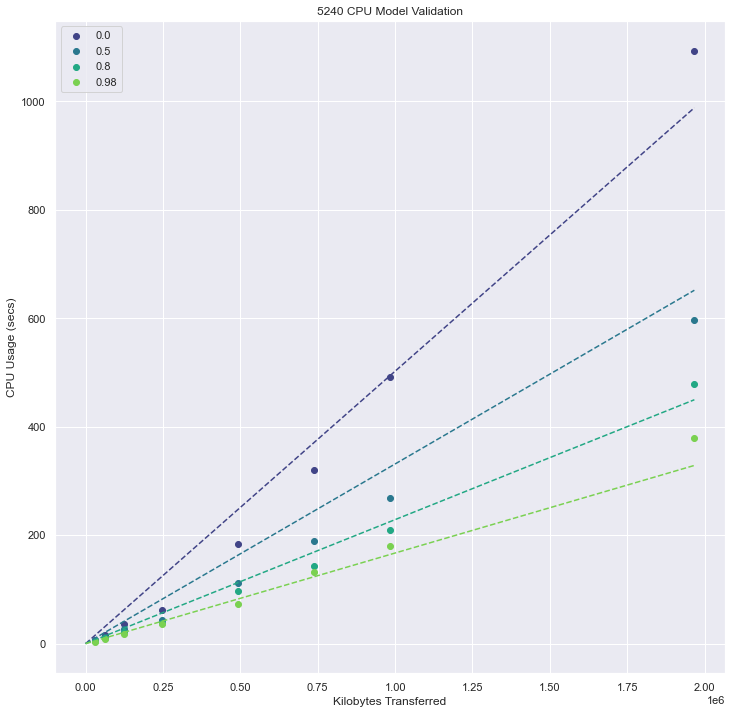

In [6]:
root_data_dir = pathlib.Path("../data")
data_dir_5240 = root_data_dir / "5240/8.2/default"
cpu_data = build_models.get_cpu_data(data_dir_5240, "backup", "default", "5240")
dedup_cat = cpu_data["dedup_ratio"].astype("category")
colors = sns.color_palette("viridis", 4)

max_kb_transferred = cpu_data["kb_transferred"].max()

fig, ax = plt.subplots(figsize=(12, 12))
for i, ddr in enumerate(dedup_cat.cat.categories):
    # Scatter points
    subset_dat = cpu_data.loc[cpu_data["dedup_ratio"] == ddr]
    ax.scatter(subset_dat["kb_transferred"], subset_dat["cpu_usage_secs"], c=[colors[i]], label=str(ddr))

    # Fitted line
    input_range = np.linspace(0, max_kb_transferred, 1000)
    pred_vals = fitted_model.predict(pd.DataFrame({"kb_transferred": input_range, "dedup_ratio": [ddr] * len(input_range), "swapout": [0] * len(input_range)}))
    ax.plot(input_range, pred_vals, c=colors[i], ls="--")
ax.set(title="5240 CPU Model Validation", xlabel="Kilobytes Transferred", ylabel="CPU Usage (secs)")
ax.legend(loc="upper left");

In [7]:
## 5340

In [8]:
mock_run_config = MockRunConfig(0.47, 1000000, 10, "backup", "default", task.TaskDuplexType.half)
mock_appliance_config = MockApplianceConfig("5340", constants.SoftwareVersion.VER8_2, 256 * 1024 * 1024, 4)
ri = run_info.RunInfo(mock_run_config,
                      mock_appliance_config,
                      retrain=True,
                      root_data_dir="../data",
                      model_dir="../src/core/use_core/conf/models")

In [9]:
fitted_model = ri.cpu_model
# ignore the RuntimeWarning
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    summary = fitted_model.summary()
summary

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:         cpu_usage_secs   R-squared (uncentered):                   0.995
Model:                            OLS   Adj. R-squared (uncentered):              0.995
Method:                 Least Squares   F-statistic:                              3237.
Date:                Mon, 05 Oct 2020   Prob (F-statistic):                    9.11e-36
Time:                        15:34:10   Log-Likelihood:                         -95.641
No. Observations:                  32   AIC:                                      195.3
Df Residuals:                      30   BIC:                                      198.2
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================================
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
kb_transferred                 0.0001    1.9e-06     65.393      0.000       0.000       0.000
kb_transferred:dedup_ratio -8.186e-05    2.8e-06    -29.228      0.000   -8.76e-05   -7.61e-05
swapout                             0          0        nan        nan           0           0
==============================================================================
Omnibus:                        2.191   Durbin-Watson:                   1.627
Prob(Omnibus):                  0.334   Jarque-Bera (JB):                1.047
Skew:                          -0.174   Prob(JB):                        0.592
Kurtosis:                       3.815   Cond. No.                          inf
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[3] The smallest eigenvalue is      0. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

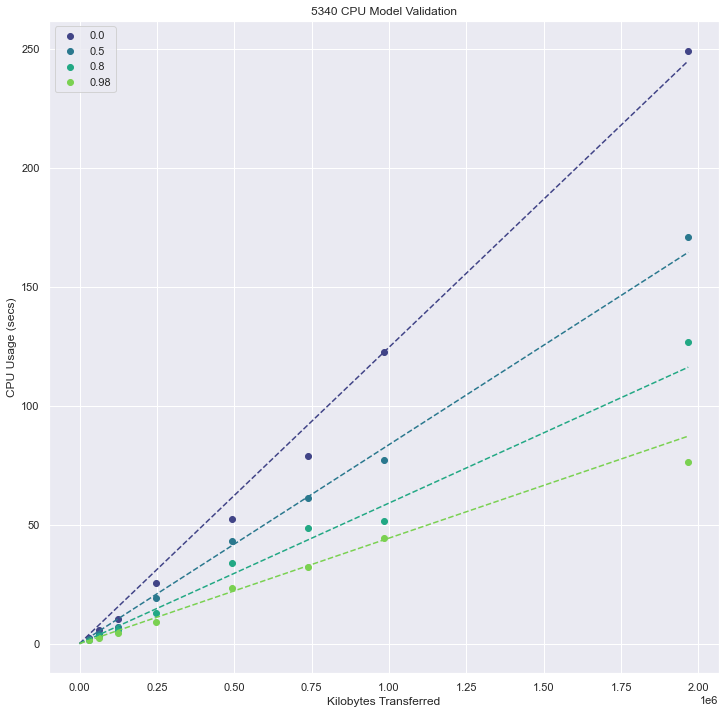

In [10]:
root_data_dir = pathlib.Path("../data")
data_dir_5340 = root_data_dir / "5340/8.2/default"
cpu_data = build_models.get_cpu_data(data_dir_5340, "backup", "default", "5340")
dedup_cat = cpu_data["dedup_ratio"].astype("category")
colors = sns.color_palette("viridis", 4)

max_kb_transferred = cpu_data["kb_transferred"].max()

fig, ax = plt.subplots(figsize=(12, 12))
for i, ddr in enumerate(dedup_cat.cat.categories):
    # Scatter points
    subset_dat = cpu_data.loc[cpu_data["dedup_ratio"] == ddr]
    ax.scatter(subset_dat["kb_transferred"], subset_dat["cpu_usage_secs"], c=[colors[i]], label=str(ddr))

    # Fitted line
    input_range = np.linspace(0, max_kb_transferred, 1000)
    pred_vals = fitted_model.predict(pd.DataFrame({"kb_transferred": input_range, "dedup_ratio": [ddr] * len(input_range), "swapout": [0] * len(input_range)}))
    ax.plot(input_range, pred_vals, c=colors[i], ls="--")
ax.set(title="5340 CPU Model Validation", xlabel="Kilobytes Transferred", ylabel="CPU Usage (secs)")
ax.legend(loc="upper left");